# Ewaluacja CohortFACTM na danych COVID-19 (Su et al.) — kompletny notebook

Ten notebook zbiera w jednym miejscu **wszystkie** testy kohortowe uruchamiane do tej
pory na osobnych notebookach i odpala je na **realnych** danych multi-omicznych COVID-19
(metabolom + proteom, `covid_data.load_covid`). Dla każdego testu porównujemy
**CohortFACTM** (`ZPrior.COHORT`, spike-and-slab prior na efekt kohortowy) z
**baseline FACTM** (`ZPrior.STD_NORMAL`, brak struktury kohortowej) i tłumaczymy, co
dany test mierzy oraz jak czytać wynik.

Mapowanie ze źródłowych notebooków:

| Sekcja | Źródło | Co robimy |
|--------|--------|-----------|
| 1 | `covid_cohort_tests` | wczytanie 3 partycji kohort (per_severity / grouped / binary) |
| 2 | `covid_cohort_tests` Exp 1 **+ rozszerzenie** | `E[γ]`, `E[γ·δ]`; iteracja po `K = 3…10, 15, 20` + R²/istotne faktory |
| 3 | `covid_cohort_tests` Exp 2 | partycja `grouped` (mild / moderate / severe) |
| 4 | `covid_cohort_tests` Exp 3 | partycja `binary` (non_hosp / hosp) |
| 5 | `covid_cohort_tests` Exp 4–5 | struktura odległości kohort + korelacja z nasileniem WHO |
| 6 | `01_pi_tests` | sweep `pi = P(γ=1)` dla `K ∈ {3, 5, 10}` na danych COVID |
| 7 | `03` + nowe | struktura czynników `Z` (korelacje, powiązanie z WHO, centroidy) |
| 8 | `03_correlations_clustering` + `04_distance_tests` | klastrowanie: czy CohortFACTM wykrywa kohorty? odzysk cohort vs baseline + komplet metryk (silhouette, DB, CH, ARI, NMI, AMI, V-measure, FMI) |
| 9 | `02_w_loadings` | ładunki `W` i istotność faktorów (energia, ARD) |
| 10 | — | podsumowanie i werdykt |

**Brak ground-truth.** FACTM uczy się nienadzorowanie — prawdziwych `Z`/`W`/`μ` nie
znamy. Jako „miękki" ground-truth używamy **WHO Ordinal Scale (0–7)**: prawidłowo
dopasowany prior kohortowy powinien zachować gradient nasilenia w przestrzeni utajonej.

> **Uwaga o czasie.** Notebook dopasowuje ~36 modeli (`MAX_ITER=60` — kompromis między
> czasem a zbieżnością przy dużej siatce `K × pi` na 8 kohortach; `K=15,20` są kosztowne).
> Wszystkie dopasowania są cache'owane w słowniku `FITS`, więc identyczne konfiguracje
> liczą się tylko raz — np. fit `per_severity, K=5, pi=0.3` współdzielony przez sekcje
> 2, 5, 6, 7, 8 i 9. Pełny przebieg to ~30 min.


## 0 — Setup: importy, konfiguracja i funkcje pomocnicze

Funkcje pomocnicze są wspólne dla wszystkich sekcji i pochodzą wprost ze źródłowych
notebooków:

* `fit_cohort` / `fit_baseline` — dopasowanie CohortFACTM vs baseline (identyczna
  konfiguracja widoków, różni się tylko prior na `Z`).
* `extract_cohort_effects` / `cohort_gamma_delta` — wyciągnięcie `E[γ]`, `E[δ]` z priora.
* `cohort_dist`, `hungarian`, `w_stability` — odległości i dopasowanie czynników.
* `get_W`, `factor_alpha`, `reconstruct`, `r2_view`, `n_relevant_factors`, `mean_r2` —
  ładunki, istotność ARD i jakość rekonstrukcji.
* `clustering_metrics`, `cluster_cohorts`, `cluster_samples` — metryki separacji kohort
  (wewnętrzne + zewnętrzne: ARI/NMI/AMI/V-measure/FMI).
* `get_data` / `get_fit` — leniwe, cache'owane wczytywanie danych i dopasowania modeli.


In [1]:
import os, sys, time, warnings
sys.path.insert(0, os.path.abspath('..'))   # repo root (notebook żyje w cohort_tests_notebooks/)
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score,
                             adjusted_mutual_info_score, fowlkes_mallows_score,
                             homogeneity_completeness_v_measure)
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from covid_data.load_covid import load_covid

# Wyłącz paski postępu tqdm: każda aktualizacja to wiadomość IOPub, a na Windows
# (proactor + dodatkowy wątek selektora dla zmq) jest to ~8x wolniejsze niż samo
# dopasowanie. Bez tego pojedynczy fit K=10 potrafi „wisieć" wiele minut.
import src.build_model as _bm
_bm.tqdm = lambda x, *a, **k: x

sns.set_context('notebook')
pd.set_option('display.width', 120)

# ----- globalne ustawienia eksperymentów -----
HEADLINE_K = 5      # K dla głównych eksperymentów (jak w covid_cohort_tests)
PI         = 0.3    # spike-and-slab P(gamma=1) dla głównych eksperymentów
MAX_ITER   = 60     # iteracje CAVI (zredukowane z 100 — duża siatka K x pi na 8 kohortach)
SEED       = 0
print(f'HEADLINE_K={HEADLINE_K}  PI={PI}  MAX_ITER={MAX_ITER}  SEED={SEED}')

HEADLINE_K=5  PI=0.3  MAX_ITER=60  SEED=0


In [2]:
# ----------------------- dopasowanie modeli -----------------------
def fit_cohort(views, K, pi=PI, max_iter=MAX_ITER, seed=SEED):
    '''CohortFACTM: WPrior.ARD_SS + ZPrior.COHORT, spike-and-slab prior `pi`.'''
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL,
                                              w_prior=WPrior.ARD_SS)
                             for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.COHORT] * K,
        cohort_prior_config=CohortPriorConfig(pi=pi),
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def fit_baseline(views, K, max_iter=MAX_ITER, seed=SEED):
    '''Standardowy FACTM z izotropowym priorem N(0,1) — bez struktury kohortowej.'''
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL,
                                              w_prior=WPrior.ARD_SS)
                             for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.STD_NORMAL] * K,
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def cohort_gamma_delta(model, K):
    '''Macierze (C, K): E[gamma] i E[delta]. Wiersze wg np.unique(cohorts).'''
    priors = model.fa.node_z.z_priors
    assert priors[0].__class__.__name__ == 'CohortZPrior', 'model nie ma cohort-prior'
    E_g = np.column_stack([priors[k].E_gamma for k in range(K)])
    E_d = np.column_stack([priors[k].E_delta for k in range(K)])
    return E_g, E_d


def extract_cohort_effects(model, cohort_labels, K):
    '''E[gamma], E[delta], nazwy kohort i ELBO z dopasowanego modelu kohortowego.'''
    E_g, E_d = cohort_gamma_delta(model, K)
    return {'E_gamma': E_g, 'E_delta': E_d,
            'cohorts': np.array(sorted(np.unique(cohort_labels))),
            'elbo': float(model.elbo_sequence[-1])}

In [3]:
# --------------- odległości / Hungarian / stabilność W ---------------
def cohort_dist(M):
    '''Parami odległość L2 między wierszami M (pozycje kohort w przestrzeni utajonej).'''
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


def cohort_positions(model, K):
    '''(C, K) pozycje kohort w przestrzeni utajonej z E[gamma * delta].'''
    pr = model.fa.node_z.z_priors
    return np.column_stack([pr[k].E_gamma * pr[k].E_delta for k in range(K)])


def hungarian(Z_a, Z_b):
    '''Dopasuj kolumny Z_b do Z_a maksymalizując sumę |corr|; zwraca perm i znaki.'''
    K = Z_a.shape[1]
    corr = np.array([[np.corrcoef(Z_a[:, i], Z_b[:, j])[0, 1]
                      for j in range(K)] for i in range(K)])
    row, col = linear_sum_assignment(-np.abs(corr))
    signs = np.sign(corr[row, col]); signs[signs == 0] = 1
    return col, signs.astype(float)


def w_stability(model_a, model_b, K):
    '''Per-widok per-czynnik |corr(W_a, W_b)| po dopasowaniu czynników przez Z.'''
    perm, signs = hungarian(model_a.get_latent_factors(),
                            model_b.get_latent_factors())
    out = []
    for v in range(len(model_a.fa.nodelist_w)):
        Wa = model_a.fa.nodelist_w[v].E_w
        Wb = model_b.fa.nodelist_w[v].E_w
        out.append(np.array([abs(np.corrcoef(Wa[:, k], Wb[:, perm[k]] * signs[k])[0, 1])
                             for k in range(K)]))
    return out, perm, signs


def severity_from_label(label):
    '''Etykieta kohorty -> wartość WHO (lub środek przedziału).'''
    s = str(label).strip().lower()
    if s in ('mild', 'moderate', 'severe'):
        return {'mild': 0.5, 'moderate': 3.0, 'severe': 6.0}[s]
    if s.startswith('sev') and s[3:].isdigit():
        return float(s[3:])
    if '-' in s:
        a, b = s.split('-'); return (float(a) + float(b)) / 2
    if s == 'non_hosp':
        return 1.0
    if s == 'hosp':
        return 5.0
    return float('nan')

In [4]:
# --------------- metryki klastrowania ---------------
def clustering_metrics(X, labels):
    '''silhouette / Calinski-Harabasz: wyżej=lepiej; Davies-Bouldin / within-between: niżej=lepiej.'''
    out = {}
    out['silhouette'] = float(silhouette_score(X, labels))
    out['davies_bouldin'] = float(davies_bouldin_score(X, labels))
    out['calinski_harabasz'] = float(calinski_harabasz_score(X, labels))
    uniq = np.unique(labels)
    cents = np.array([X[labels == c].mean(0) for c in uniq])
    within = np.mean([np.linalg.norm(X[labels == c] - cents[i], axis=1).mean()
                      for i, c in enumerate(uniq)])
    bp = cents[:, None, :] - cents[None, :, :]
    between = np.sqrt((bp ** 2).sum(-1))[np.triu_indices(len(cents), 1)].mean()
    out['within/between'] = float(within / between)
    return out


def cluster_cohorts(D, k_range=(2, 3, 4)):
    '''Agglomerative + k-means + spectral na macierzy odległości (C, C); silhouette per metoda.'''
    C = D.shape[0]
    rows, labels = [], {}
    coords = MDS(n_components=min(C - 1, 5), dissimilarity='precomputed',
                 random_state=0, n_init=4).fit_transform(D)
    for k in k_range:
        if k >= C:
            continue
        agg = AgglomerativeClustering(n_clusters=k, metric='precomputed',
                                      linkage='average').fit(D)
        sil_agg = silhouette_score(D, agg.labels_, metric='precomputed') \
            if len(set(agg.labels_)) > 1 else np.nan
        rows.append({'method': 'agglomerative', 'k': k, 'silhouette': sil_agg})
        labels[('agglomerative', k)] = agg.labels_
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(coords)
        sil_km = silhouette_score(D, km.labels_, metric='precomputed') \
            if len(set(km.labels_)) > 1 else np.nan
        rows.append({'method': 'kmeans', 'k': k, 'silhouette': sil_km})
        labels[('kmeans', k)] = km.labels_
        gamma = 1.0 / (2 * (D[D > 0].mean() ** 2 + 1e-9))
        A = np.exp(-gamma * D ** 2)
        sp = SpectralClustering(n_clusters=k, affinity='precomputed',
                                random_state=0, assign_labels='kmeans').fit(A)
        sil_sp = silhouette_score(D, sp.labels_, metric='precomputed') \
            if len(set(sp.labels_)) > 1 else np.nan
        rows.append({'method': 'spectral', 'k': k, 'silhouette': sil_sp})
        labels[('spectral', k)] = sp.labels_
    return pd.DataFrame(rows), labels


def cluster_samples(Z, true_labels, k_range=(2, 3, 4)):
    '''Klastruj N próbek w Z; silhouette + ARI/NMI vs prawdziwe etykiety kohort.'''
    rows, labels = [], {}
    true = np.asarray(true_labels)
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
        agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(Z)
        for name, lab in [('kmeans', km.labels_), ('agglomerative', agg.labels_)]:
            sil = silhouette_score(Z, lab) if len(set(lab)) > 1 else np.nan
            h, comp, v = homogeneity_completeness_v_measure(true, lab)
            rows.append({'method': name, 'k': k, 'silhouette': sil,
                         'ARI': adjusted_rand_score(true, lab),
                         'NMI': normalized_mutual_info_score(true, lab),
                         'AMI': adjusted_mutual_info_score(true, lab),
                         'V_measure': v,
                         'FMI': fowlkes_mallows_score(true, lab)})
            labels[(name, k)] = lab
    if len(set(true)) > 1:
        rows.append({'method': 'TRUE_LABELS', 'k': len(set(true)),
                     'silhouette': silhouette_score(Z, true),
                     'ARI': 1.0, 'NMI': 1.0, 'AMI': 1.0,
                     'V_measure': 1.0, 'FMI': 1.0})
    return pd.DataFrame(rows), labels

In [5]:
# --------------- ładunki W, istotność faktorów, rekonstrukcja ---------------
def get_W(model, view_idx=0):
    '''Macierz ładunków E[W] (D x K) dla widoku prostego.'''
    return np.asarray(model.fa.nodelist_w[view_idx].E_w)


def factor_alpha(model, view_idx=0):
    '''ARD precyzja E[alpha] per faktor (małe = istotny, duże = wygaszony przez ARD).
    Fallback do 1/energia gdy węzeł ARD nie wystawia E_alpha.'''
    wn = model.fa.nodelist_w[view_idx]
    for attr in ('alpha_m_node', 'node_alpha', 'alpha_node'):
        node = getattr(wn, attr, None)
        if node is not None and hasattr(node, 'E_alpha'):
            return np.asarray(node.E_alpha)
    e = np.linalg.norm(np.asarray(wn.E_w), axis=0)
    return 1.0 / np.maximum(e, 1e-9)


def reconstruct(model, views, view_idx=0):
    '''Zwraca (Y, Y_hat = Z·Wᵀ) — obserwacje i rekonstrukcja widoku z modelu.'''
    Z = np.asarray(model.get_latent_factors())
    W = get_W(model, view_idx)
    Y = np.asarray(views.simple[view_idx].data)
    return Y, Z @ W.T


def r2_view(Y, Yh):
    '''R² całego widoku (1 = idealna rekonstrukcja).'''
    return 1.0 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()


def n_relevant_factors(model, view_idx=0, rel_thr=0.05):
    '''Liczba faktorów o względnej energii ładunków ‖W[:,k]‖ > rel_thr * max.'''
    e = np.linalg.norm(get_W(model, view_idx), axis=0)
    return int((e / e.max() > rel_thr).sum()) if e.max() > 0 else 0


def mean_r2(model, views):
    '''Średnie R² rekonstrukcji po wszystkich widokach prostych.'''
    return float(np.mean([r2_view(*reconstruct(model, views, vi))
                          for vi in range(views.num_simple)]))


def abscorr(a, b):
    '''|corr| odporne na stałe kolumny (zwraca nan zamiast błędu).'''
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return abs(np.corrcoef(a, b)[0, 1])

In [6]:
# --------------- leniwy, cache'owany dostęp do danych i dopasowań ---------------
DATA = {}
FITS = {}


def get_data(mode):
    if mode not in DATA:
        DATA[mode] = load_covid(cohort_mode=mode, standardize=True)
    return DATA[mode]


def get_fit(mode, kind, K=HEADLINE_K, pi=PI, max_iter=MAX_ITER, seed=SEED):
    '''Dopasuj (lub pobierz z cache) model `kind` ('cohort'/'baseline') dla danej partycji.'''
    key = (mode, kind, K, round(float(pi), 3), max_iter, seed)
    if key in FITS:
        return FITS[key]
    views = get_data(mode).views
    t0 = time.time()
    if kind == 'cohort':
        m = fit_cohort(views, K=K, pi=pi, max_iter=max_iter, seed=seed)
    elif kind == 'baseline':
        m = fit_baseline(views, K=K, max_iter=max_iter, seed=seed)
    else:
        raise ValueError(kind)
    print(f'  [fit] {mode:12s} {kind:8s} K={K:<2d} pi={pi:<4} -> '
          f'ELBO={float(m.elbo_sequence[-1]):.0f}  ({time.time()-t0:.0f}s)')
    FITS[key] = m
    return m


def plot_cohort_effects(out, K, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(11, 0.55 * len(out['cohorts']) + 2))
    sns.heatmap(out['E_gamma'] * out['E_delta'], annot=True, fmt='.2f', cmap='coolwarm',
                center=0, xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[0])
    axes[0].set_title(f'{title_prefix} — E[gamma·delta] (profil kohortowy)')
    sns.heatmap(out['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[1])
    axes[1].set_title(f'{title_prefix} — E[gamma] (aktywacja)')
    plt.tight_layout(); plt.show()

## 1 — Wczytanie danych i przegląd partycji kohort

Tak jak w `covid_cohort_tests`: dwa widoki proste (metabolom + proteom), wyrównane po
`sample_id`, z-score'owane per cecha. Etykieta kohorty pochodzi z WHO Ordinal Scale w
trzech wariantach podziału. Poniżej liczności każdej partycji — niektóre poziomy
nasilenia (`sev2`) są bardzo małe, więc ich efekt kohortowy będzie z natury niepewny.


In [7]:
for mode in ['per_severity', 'grouped', 'binary']:
    d = get_data(mode)
    print(f'=== {mode} ===  N={d.views.N}  D_metab={d.views.simple[0].D}  D_prot={d.views.simple[1].D}')
    print(pd.Series(d.cohorts).value_counts().sort_index().to_string(), '\n')

=== per_severity ===  N=378  D_metab=1050  D_prot=464
sev0    124
sev1    104
sev2      2
sev3     44
sev4     55
sev5     22
sev6     12
sev7     15 

=== grouped ===  N=378  D_metab=1050  D_prot=464
mild        228
moderate    101
severe       49 



=== binary ===  N=378  D_metab=1050  D_prot=464
hosp        148
non_hosp    230 



## 2 — Eksperyment 1: `per_severity` + iteracja po `K = 3…10, 15, 20`

**Część A (jak w covid_cohort_tests Exp 1).** Jedna kohorta na wartość WHO (`sev0`…`sev7`).
Patrzymy na `E[γ]` (które czynniki aktywują się jako kohortowe) i `E[γ·δ]` (pełny profil
przesunięć). Oczekiwanie: małe kohorty (`sev2`) mają niskie `γ` (prior je tłumi).

**Część B (rozszerzenie — sweep `K`).** Powtarzamy dopasowanie dla `K = 3…10, 15, 20` i
śledzimy: ELBO (cohort vs baseline), liczbę aktywnych czynników kohortowych
(`mean E[γ] > 0.5`), **R² rekonstrukcji** (`Z·Wᵀ` vs dane, średnia po widokach) oraz
**liczbę istotnych faktorów** (energia ładunków `‖W[:,k]‖ > 5% max` — z `02_w_loadings`).
Pozwala to zobaczyć, ile czynników model faktycznie wykorzystuje i czy dokładanie wymiarów
`K` przestaje pomagać („łokieć" na R² / plateau ELBO). Duże `K` (15, 20) są kosztowne na
8 kohortach — stąd cache.


Pretraining FA


Fitting model


  [fit] per_severity cohort   K=5  pi=0.3  -> ELBO=-676522  (24s)
Pretraining FA


Fitting model


  [fit] per_severity baseline K=5  pi=0.3  -> ELBO=-678492  (24s)
ELBO  cohort=-676522   baseline=-678492


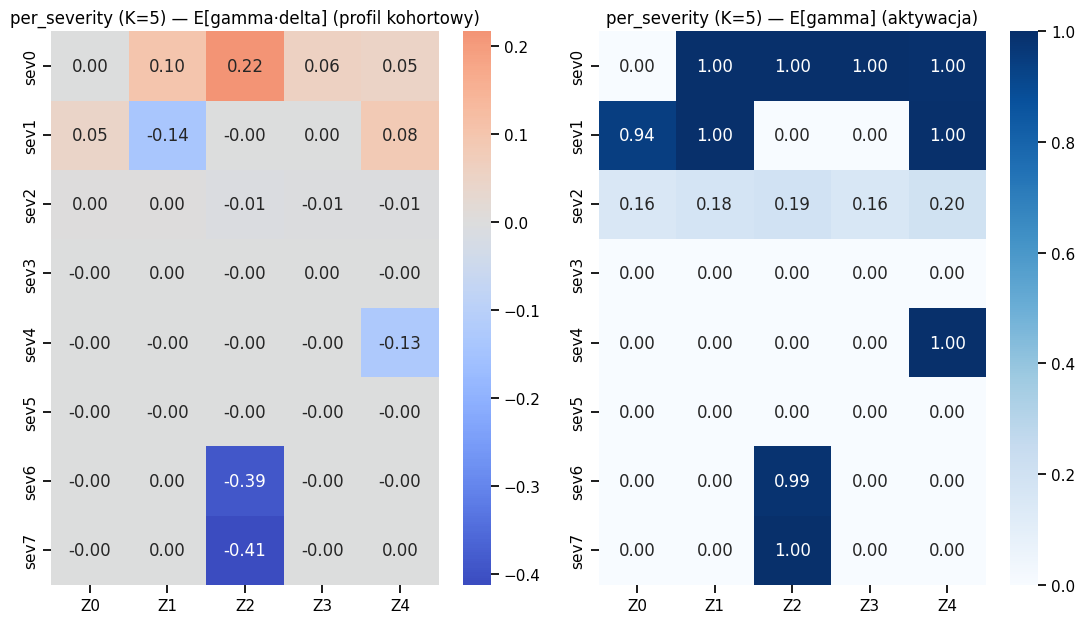

In [8]:
# --- Część A: headline K=5 ---
mode = 'per_severity'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'per_severity (K=5)')

In [9]:
# --- Część B: sweep K = 3..10, 15, 20 ---
K_RANGE = [3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
ACTIVE_THR = 0.5
views = get_data(mode).views
rows = []
for K in K_RANGE:
    mc = get_fit(mode, 'cohort',   K=K)
    mbk = get_fit(mode, 'baseline', K=K)
    E_g, _ = cohort_gamma_delta(mc, K)
    g_mean = E_g.mean(axis=0)
    rows.append({'K': K,
                 'elbo_cohort':   float(mc.elbo_sequence[-1]),
                 'elbo_baseline': float(mbk.elbo_sequence[-1]),
                 'n_active': int((g_mean > ACTIVE_THR).sum()),
                 'n_relevant_W': n_relevant_factors(mc, 0),
                 'R2_cohort': mean_r2(mc, views),
                 'R2_baseline': mean_r2(mbk, views)})
df_K = pd.DataFrame(rows)
df_K['elbo_gap'] = df_K['elbo_cohort'] - df_K['elbo_baseline']
print(df_K.round(3).to_string(index=False))

Pretraining FA


Fitting model


  [fit] per_severity cohort   K=3  pi=0.3  -> ELBO=-707574  (16s)
Pretraining FA


Fitting model


  [fit] per_severity baseline K=3  pi=0.3  -> ELBO=-708752  (16s)
Pretraining FA


...

  [fit] per_severity baseline K=15 pi=0.3  -> ELBO=-626481  (73s)
Pretraining FA


Fitting model


  [fit] per_severity cohort   K=20 pi=0.3  -> ELBO=-610354  (103s)
Pretraining FA


Fitting model


  [fit] per_severity baseline K=20 pi=0.3  -> ELBO=-618605  (100s)
 K  elbo_cohort  elbo_baseline  n_active  n_relevant_W  R2_cohort  R2_baseline  elbo_gap
 3  -707574.497    -708752.132         0             3      0.335        0.335  1177.635
 4  -690598.001    -692222.431         1             4      0.357        0.357  1624.430
 5  -676521.530    -678491.713         0             5      0.392        0.392  1970.183
 6  -668917.938    -671256.332         1             6      0.412        0.412  2338.394
 7  -659425.127    -662102.772         0             7      0.447        0.447  2677.645
 8  -640815.078    -644036.680         0             8      0.462        0.462  3221.602
 9  -636446.945    -640031.795         0             9      0.475        0.475  3584.850
10  -636193.818    -640342.198         0            10      0.485        0.485  4148.380
15  -620242.838    -626480.947         0            15      0.539        0.539  6238.109
20  -610353.829    -618604.553         0   

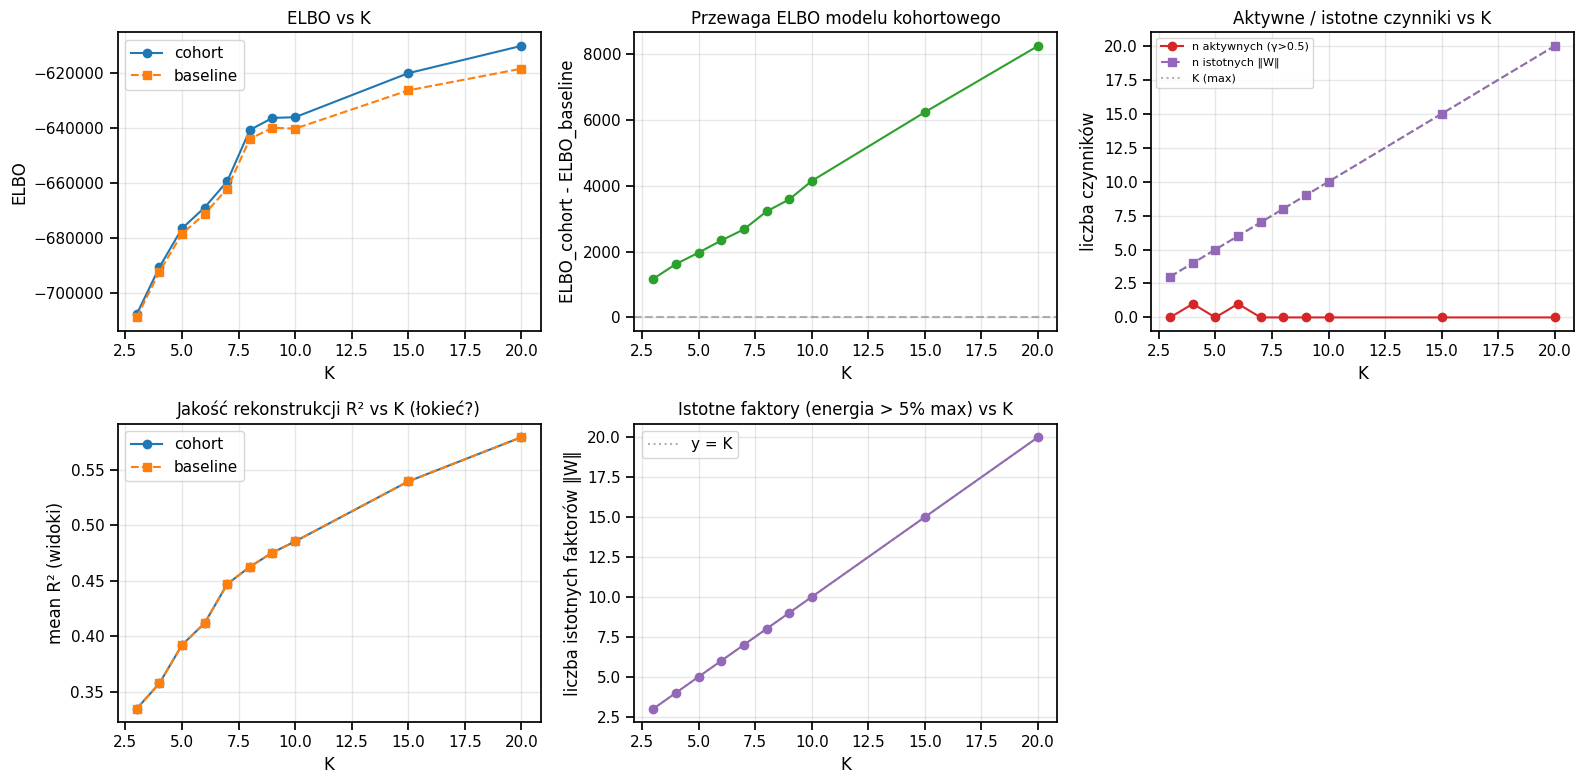

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(df_K['K'], df_K['elbo_cohort'],   'o-', label='cohort')
axes[0, 0].plot(df_K['K'], df_K['elbo_baseline'], 's--', label='baseline')
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('ELBO'); axes[0, 0].set_title('ELBO vs K')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(df_K['K'], df_K['elbo_gap'], 'o-', color='C2')
axes[0, 1].axhline(0, color='gray', ls='--', alpha=0.6)
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('ELBO_cohort - ELBO_baseline')
axes[0, 1].set_title('Przewaga ELBO modelu kohortowego'); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(df_K['K'], df_K['n_active'], 'o-', color='C3', label='n aktywnych (γ>0.5)')
axes[0, 2].plot(df_K['K'], df_K['n_relevant_W'], 's--', color='C4', label='n istotnych ‖W‖')
axes[0, 2].plot(df_K['K'], df_K['K'], ':', color='gray', alpha=0.6, label='K (max)')
axes[0, 2].set_xlabel('K'); axes[0, 2].set_ylabel('liczba czynników')
axes[0, 2].set_title('Aktywne / istotne czynniki vs K'); axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(df_K['K'], df_K['R2_cohort'],   'o-', label='cohort')
axes[1, 0].plot(df_K['K'], df_K['R2_baseline'], 's--', label='baseline')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('mean R² (widoki)')
axes[1, 0].set_title('Jakość rekonstrukcji R² vs K (łokieć?)')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(df_K['K'], df_K['n_relevant_W'], 'o-', color='C4')
axes[1, 1].plot(df_K['K'], df_K['K'], ':', color='gray', alpha=0.6, label='y = K')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('liczba istotnych faktorów ‖W‖')
axes[1, 1].set_title('Istotne faktory (energia > 5% max) vs K')
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout(); plt.show()

**Jak czytać.** Jeśli ELBO modelu kohortowego rośnie ponad baseline, prior kohortowy
pomaga wyjaśnić dane. Liczba aktywnych czynników kohortowych zwykle nasyca się znacznie
poniżej `K` — model używa kilku czynników na strukturę kohortową, resztę zostawia
„cichą" (`γ→0`), co jest pożądane (rzadka, interpretowalna reprezentacja kohort). R² rośnie
z `K`, ale po „łokciu" przyrost jest marginalny — to praktyczna górna granica sensownego
`K`; liczba istotnych faktorów `‖W‖` pokazuje, ile wymiarów realnie niesie sygnał (ARD
wygasza nadmiarowe). Cohort i baseline mają niemal identyczne R² — prior kohortowy dokłada
strukturę kohort bez psucia rekonstrukcji.


## 3 — Eksperyment 2: `grouped` (mild / moderate / severe)

Binowanie kliniczne: `0-1` (mild), `2-4` (moderate), `5-7` (severe). Wyrównuje liczności
kohort (228 / 101 / 49) i wchłania bardzo małą klasę `sev2` do `moderate`.


Pretraining FA


Fitting model


  [fit] grouped      cohort   K=5  pi=0.3  -> ELBO=-676305  (25s)
Pretraining FA


Fitting model


  [fit] grouped      baseline K=5  pi=0.3  -> ELBO=-678492  (25s)
ELBO  cohort=-676305   baseline=-678492


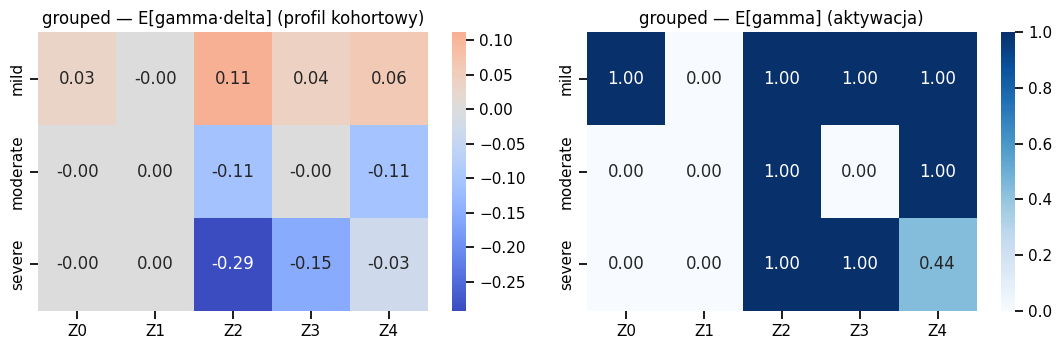

In [11]:
mode = 'grouped'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'grouped')

## 4 — Eksperyment 3: `binary` (non_hosp / hosp)

Podział ordynalny na WHO = 3 (`0-2` vs `3-7`), tj. niehospitalizowani vs hospitalizowani.
Najbliżej klasycznego case/control — maksymalnie prosta partycja kohort.


Pretraining FA


Fitting model


  [fit] binary       cohort   K=5  pi=0.3  -> ELBO=-676294  (25s)
Pretraining FA


Fitting model


  [fit] binary       baseline K=5  pi=0.3  -> ELBO=-678492  (25s)
ELBO  cohort=-676294   baseline=-678492


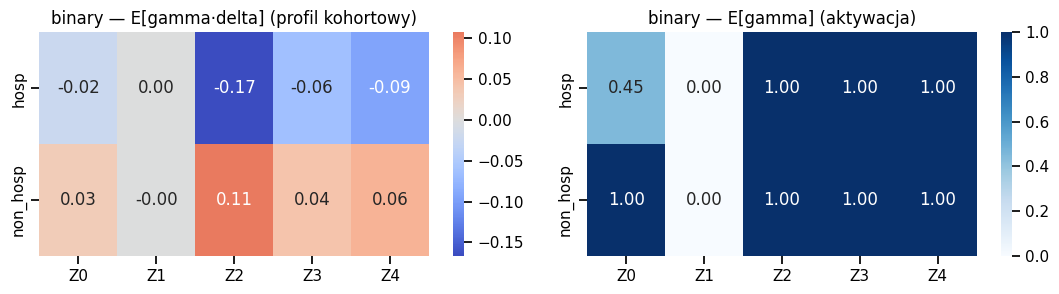

In [12]:
mode = 'binary'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'binary')

## 5 — Eksperyment 4–5: struktura odległości kohort i korelacja z nasileniem

**Exp 4 — struktura odległości.** Parami odległość L2 między pozycjami kohort
`E[γ·δ]` w przestrzeni utajonej, jedna heatmapa na partycję. Sąsiednie nasilenia
(`sev0`/`sev1`) powinny być bliżej niż odległe (`sev0`/`sev7`).

**Exp 5 — odległość vs nasilenie WHO (kluczowy test).** Ponieważ skala WHO jest
ordynalna, odległości kohort *powinny* korelować z `|sev_i − sev_j|`. Liczymy korelację
Pearsona na górnym trójkącie macierzy odległości i porównujemy **cohort** (`E[γ·δ]`) z
**baseline** (średnie `Z_hat` per kohorta — najbliższy odpowiednik bez jawnego priora).


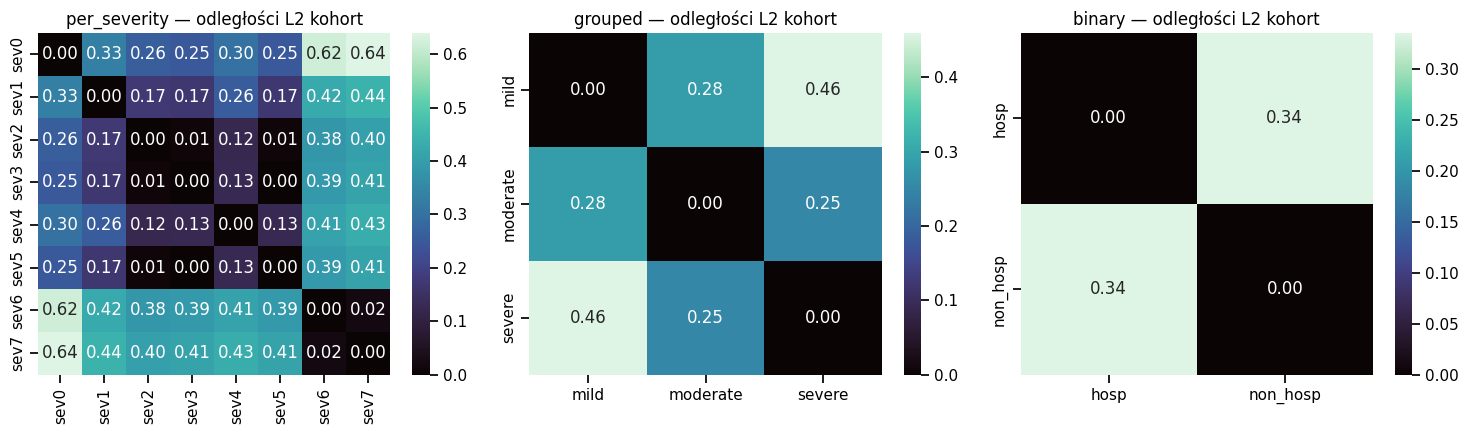

In [13]:
# Exp 4 — heatmapy odległości L2 dla trzech partycji
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mode in zip(axes, ['per_severity', 'grouped', 'binary']):
    m = get_fit(mode, 'cohort', K=HEADLINE_K)
    out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
    M = out['E_gamma'] * out['E_delta']
    D = cohort_dist(M)
    sns.heatmap(D, annot=True, fmt='.2f', cmap='mako',
                xticklabels=out['cohorts'], yticklabels=out['cohorts'], ax=ax)
    ax.set_title(f'{mode} — odległości L2 kohort')
plt.tight_layout(); plt.show()

In [14]:
# Exp 5 — korelacja odległości z |różnicą nasilenia WHO|, cohort vs baseline
rows = []
for mode in ['grouped', 'per_severity']:
    mc = get_fit(mode, 'cohort',   K=HEADLINE_K)
    mb = get_fit(mode, 'baseline', K=HEADLINE_K)
    d  = get_data(mode)
    out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
    names = out['cohorts']

    D_fit = cohort_dist(out['E_gamma'] * out['E_delta'])                 # cohort
    Zh = mb.get_latent_factors()
    Z_means = np.array([Zh[d.cohorts == c].mean(axis=0) for c in names])
    D_base = cohort_dist(Z_means)                                        # baseline

    sev = np.array([severity_from_label(c) for c in names])
    D_sev = np.abs(sev[:, None] - sev[None, :])
    tri = np.triu_indices(len(names), 1)
    r_c = float(np.corrcoef(D_fit[tri],  D_sev[tri])[0, 1])
    r_b = float(np.corrcoef(D_base[tri], D_sev[tri])[0, 1])
    rows.append({'mode': mode, 'n_cohorts': len(names),
                 'corr_cohort': r_c, 'corr_baseline': r_b,
                 'gap (cohort-baseline)': r_c - r_b})
print(pd.DataFrame(rows).round(3).to_string(index=False))

        mode  n_cohorts  corr_cohort  corr_baseline  gap (cohort-baseline)
     grouped          3        0.954          0.928                  0.026
per_severity          8        0.656          0.779                 -0.123


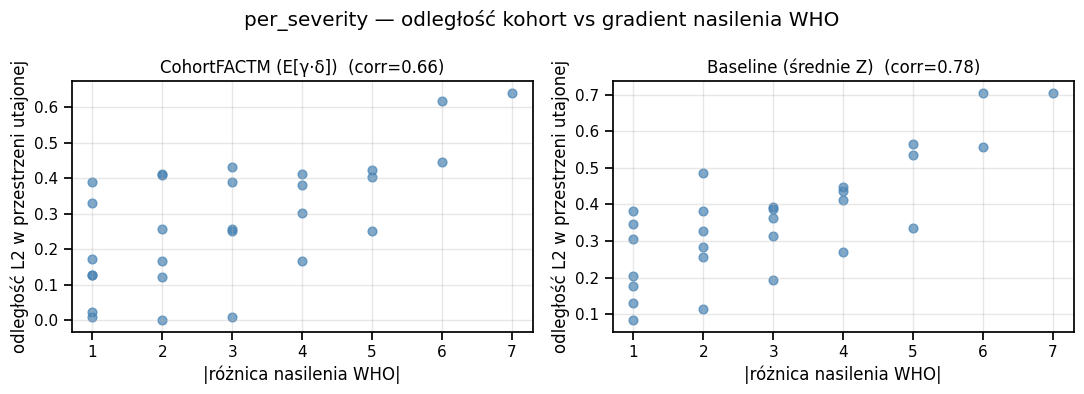

In [15]:
# Scatter: odległość utajona vs |różnica nasilenia| (per_severity), cohort vs baseline
mode = 'per_severity'
mc = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
d  = get_data(mode)
out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
names = out['cohorts']

D_c = cohort_dist(out['E_gamma'] * out['E_delta'])
Z_means = np.array([mb.get_latent_factors()[d.cohorts == c].mean(axis=0) for c in names])
D_b = cohort_dist(Z_means)
sev = np.array([severity_from_label(c) for c in names])
D_sev = np.abs(sev[:, None] - sev[None, :])
tri = np.triu_indices(len(names), 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, D_fit, label in zip(axes, [D_c, D_b], ['CohortFACTM (E[γ·δ])', 'Baseline (średnie Z)']):
    r = float(np.corrcoef(D_fit[tri], D_sev[tri])[0, 1])
    ax.scatter(D_sev[tri], D_fit[tri], s=40, alpha=0.7, color='steelblue')
    ax.set_xlabel('|różnica nasilenia WHO|'); ax.set_ylabel('odległość L2 w przestrzeni utajonej')
    ax.set_title(f'{label}  (corr={r:.2f})'); ax.grid(alpha=0.3)
plt.suptitle('per_severity — odległość kohort vs gradient nasilenia WHO')
plt.tight_layout(); plt.show()

**Oczekiwanie.** Model kohortowy powinien dorównać lub przewyższyć baseline na
`grouped`. Na `per_severity` korelacja bywa niższa, bo (i) szum czynników jest duży
względem przesunięć kohortowych, (ii) kilka poziomów nasilenia jest bardzo małych i
niestabilnych. `binary` pomijamy w Exp 5 (tylko 1 para → korelacja nieokreślona).


## 6 — Test `pi` (z `01_pi_tests`) na danych COVID dla `K ∈ {3, 5, 10}`

`pi = P(γ = 1)` to prior spike-and-slab decydujący, jak chętnie model uznaje czynnik za
**różniący kohorty**. Na danych syntetycznych w `01_pi_tests` sweep `pi` pokazywał, że
czynniki o silnym sygnale są aktywne w całym zakresie, a ciche zaczynają się fałszywie
aktywować dopiero przy dużym `pi`. Tutaj odtwarzamy ten test na realnych danych COVID
(`per_severity`, 8 kohort) dla trzech wartości `K`.

Dla każdej pary `(K, pi)` zbieramy: średnie `E[γ]` per czynnik → liczbę aktywnych
czynników (`mean E[γ] > 0.5`) oraz ELBO.


In [16]:
PI_GRID = [0.1, 0.3, 0.5, 0.7, 0.9]
K_FOR_PI = [3, 5, 10]
mode = 'per_severity'
ACTIVE_THR = 0.5

rows = []
gamma_maps = {}   # K -> (n_factors, n_pi) macierz mean E[gamma]
for K in K_FOR_PI:
    cols = []
    for pi in PI_GRID:
        mp = get_fit(mode, 'cohort', K=K, pi=pi)
        E_g, _ = cohort_gamma_delta(mp, K)
        g_mean = E_g.mean(axis=0)
        cols.append(g_mean)
        rows.append({'K': K, 'pi': pi,
                     'n_active': int((g_mean > ACTIVE_THR).sum()),
                     'max_mean_gamma': float(g_mean.max()),
                     'elbo': float(mp.elbo_sequence[-1])})
    gamma_maps[K] = np.array(cols).T   # (K, len(PI_GRID))
df_pi = pd.DataFrame(rows)
print(df_pi.round(3).to_string(index=False))

Pretraining FA


Fitting model


  [fit] per_severity cohort   K=3  pi=0.1  -> ELBO=-707569  (16s)
Pretraining FA


Fitting model


  [fit] per_severity cohort   K=3  pi=0.5  -> ELBO=-707499  (16s)
Pretraining FA


...

  [fit] per_severity cohort   K=10 pi=0.5  -> ELBO=-636201  (65s)
Pretraining FA


Fitting model


  [fit] per_severity cohort   K=10 pi=0.7  -> ELBO=-636251  (65s)
Pretraining FA


Fitting model


  [fit] per_severity cohort   K=10 pi=0.9  -> ELBO=-636250  (65s)
 K  pi  n_active  max_mean_gamma        elbo
 3 0.1         0           0.002 -707568.843
 3 0.3         0           0.015 -707574.497
 3 0.5         1           0.732 -707498.723
 3 0.7         3           0.867 -707497.661
 3 0.9         3           0.961 -707494.839
 5 0.1         0           0.003 -676649.877
 5 0.3         0           0.399 -676521.530
 5 0.5         2           0.783 -676522.292
 5 0.7         5           0.877 -676534.069
 5 0.9         5           0.962 -676531.901
10 0.1         0           0.002 -636260.052
10 0.3         0           0.273 -636193.818
10 0.5         1           0.846 -636201.149
10 0.7        10           0.920 -636251.159
10 0.9        10           0.975 -636250.329


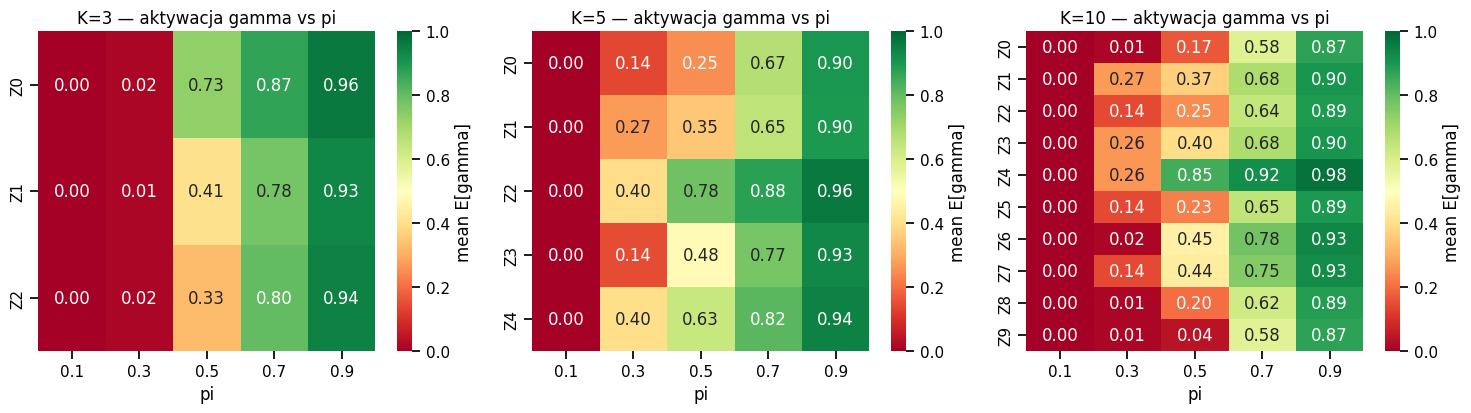

In [17]:
# Mapy aktywacji gamma (czynnik x pi) dla każdego K
fig, axes = plt.subplots(1, len(K_FOR_PI), figsize=(5 * len(K_FOR_PI), 0.8 + 0.35 * max(K_FOR_PI)))
for ax, K in zip(axes, K_FOR_PI):
    sns.heatmap(gamma_maps[K], annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=[f'{p:g}' for p in PI_GRID],
                yticklabels=[f'Z{k}' for k in range(K)],
                cbar_kws={'label': 'mean E[gamma]'}, ax=ax)
    ax.set_xlabel('pi'); ax.set_title(f'K={K} — aktywacja gamma vs pi')
plt.tight_layout(); plt.show()

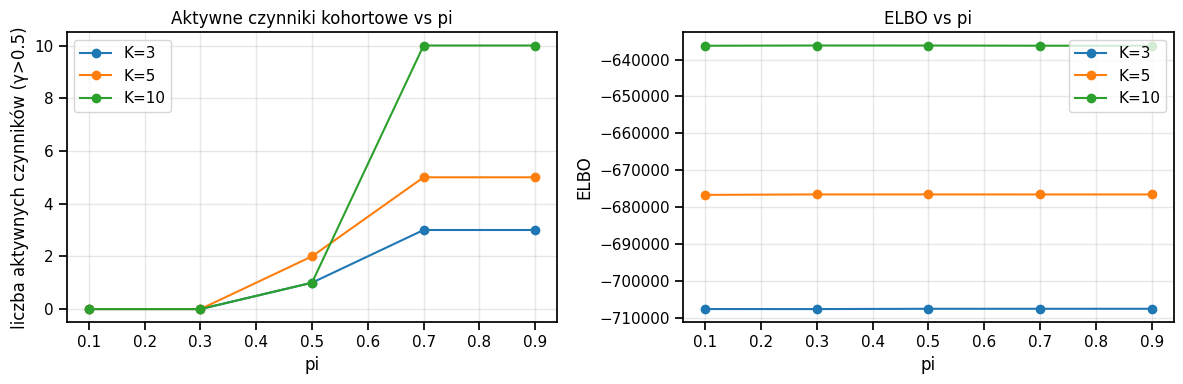

In [18]:
# n_active i ELBO vs pi dla trzech K
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for K in K_FOR_PI:
    sub = df_pi[df_pi['K'] == K]
    axes[0].plot(sub['pi'], sub['n_active'], 'o-', label=f'K={K}')
    axes[1].plot(sub['pi'], sub['elbo'],     'o-', label=f'K={K}')
axes[0].set_xlabel('pi'); axes[0].set_ylabel('liczba aktywnych czynników (γ>0.5)')
axes[0].set_title('Aktywne czynniki kohortowe vs pi'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('pi'); axes[1].set_ylabel('ELBO')
axes[1].set_title('ELBO vs pi'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretacja.** Czynniki o silnym sygnale kohortowym mają `mean E[γ]` blisko 1
niezależnie od `pi`. Czynniki ciche rosną z `pi` — przy dużym `pi` model „dopisuje"
strukturę, której nie ma. Sweet spot zwykle ~`0.3–0.5`. Większe `K` daje więcej miejsca
na ciche czynniki, ale liczba *aktywnych* zwykle pozostaje niska — model nie nadużywa
dodatkowych wymiarów do kodowania kohort.


## 7 — Struktura czynników `Z`

Zanim ocenimy separację, oglądamy **samą przestrzeń utajoną**, której nauczył się model
(`per_severity`, K=5). Trzy pytania:

1. **Czy faktory są nieskorelowane?** Macierz korelacji `corr(Zᵀ)` — wartości pozadiagonalne
   bliskie 0 oznaczają czystą, nieredundantną faktoryzację (z `03` test 2).
2. **Które faktory są „żywe" i które kodują nasilenie?** `var(Z[:,k])`, energia ładunków
   `‖W[:,k]‖` oraz `|corr(Z[:,k], WHO)|` — ostatnia wskazuje faktor niosący gradient ciężkości.
3. **Jak kohorty rozkładają się w faktorach?** Centroidy (`mean Z` per kohorta) jako heatmapa.


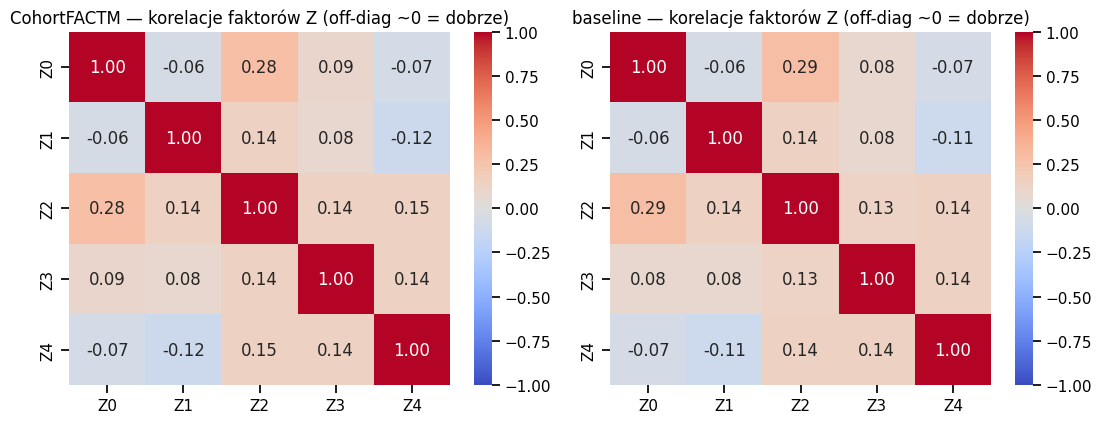

In [19]:
# 7a — korelacje między faktorami Z: cohort vs baseline
mode = 'per_severity'
mc = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
d = get_data(mode)
factors = [f'Z{k}' for k in range(HEADLINE_K)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (mdl, name) in zip(axes, [(mc, 'CohortFACTM'), (mb, 'baseline')]):
    sns.heatmap(np.corrcoef(mdl.get_latent_factors().T), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                xticklabels=factors, yticklabels=factors, ax=ax)
    ax.set_title(f'{name} — korelacje faktorów Z (off-diag ~0 = dobrze)')
plt.tight_layout(); plt.show()

    var(Z[:,k])  ‖W0[:,k]‖ (energia)  |corr(Z, WHO)|
Z0        0.043               53.458           0.173
Z1        0.024               22.534           0.004
Z2        0.050               35.475           0.756
Z3        0.022               38.579           0.439
Z4        0.023               59.871           0.425

Faktor najsilniej powiązany z nasileniem WHO: Z2  (|corr|=0.756)


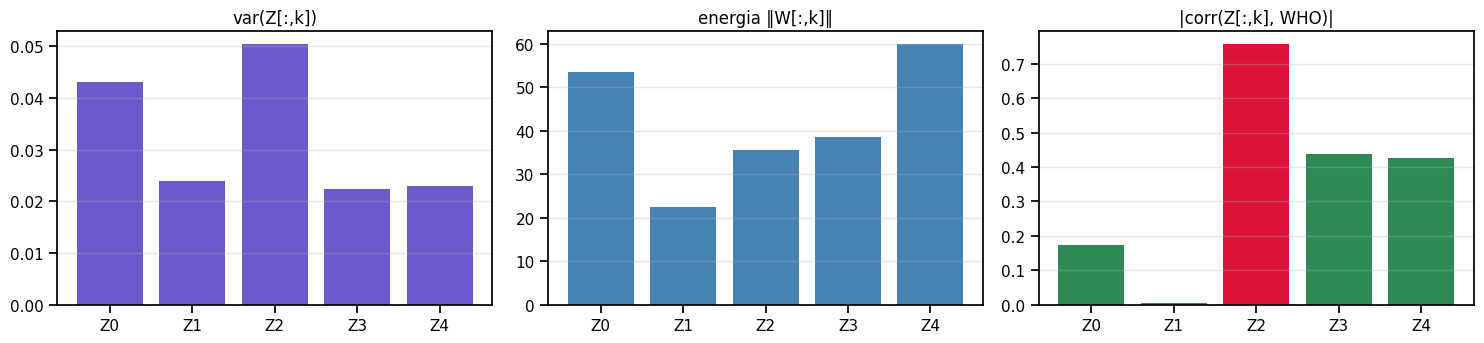

In [20]:
# 7b — istotność faktora i powiązanie z nasileniem WHO (model kohortowy)
Z = mc.get_latent_factors()
energy = np.linalg.norm(get_W(mc, 0), axis=0)
zvar = Z.var(0)
sev = d.severity.astype(float)
fac_sev = np.array([abscorr(Z[:, k], sev) for k in range(HEADLINE_K)])

tab = pd.DataFrame({'var(Z[:,k])': zvar.round(3),
                    '‖W0[:,k]‖ (energia)': energy.round(3),
                    '|corr(Z, WHO)|': fac_sev.round(3)}, index=factors)
print(tab.to_string())
print(f'\nFaktor najsilniej powiązany z nasileniem WHO: '
      f'{factors[int(np.nanargmax(fac_sev))]}  (|corr|={np.nanmax(fac_sev):.3f})')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].bar(factors, zvar, color='slateblue');  axes[0].set_title('var(Z[:,k])')
axes[1].bar(factors, energy, color='steelblue'); axes[1].set_title('energia ‖W[:,k]‖')
colors = ['crimson' if k == int(np.nanargmax(fac_sev)) else 'seagreen' for k in range(HEADLINE_K)]
axes[2].bar(factors, fac_sev, color=colors);     axes[2].set_title('|corr(Z[:,k], WHO)|')
for ax in axes:
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

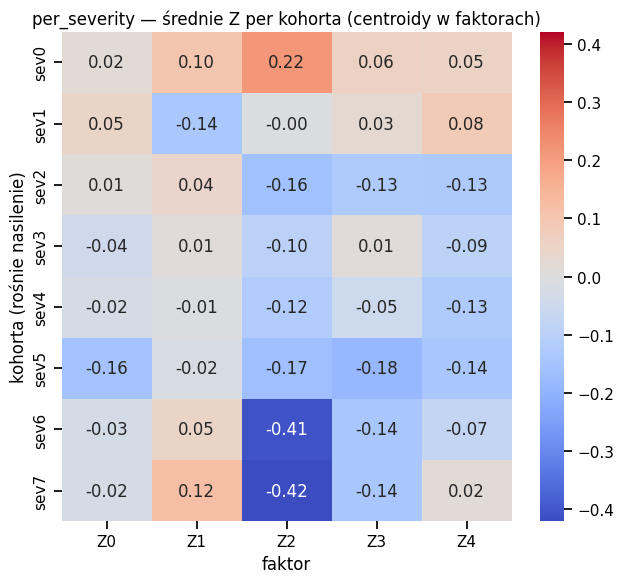

In [21]:
# 7c — centroidy kohort w przestrzeni faktorów (mean Z per kohorta)
names, codes = np.unique(d.cohorts, return_inverse=True)
cent = np.array([Z[codes == i].mean(0) for i in range(len(names))])
vmax = np.abs(cent).max()
fig, ax = plt.subplots(figsize=(6.5, 0.5 * len(names) + 2))
sns.heatmap(cent, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=factors, yticklabels=names, ax=ax)
ax.set_title('per_severity — średnie Z per kohorta (centroidy w faktorach)')
ax.set_xlabel('faktor'); ax.set_ylabel('kohorta (rośnie nasilenie)')
plt.tight_layout(); plt.show()

**Jak czytać.** Mały off-diagonal w `corr(Z)` = faktory niezależne. Faktor z wysokim
`|corr(Z, WHO)|` to „oś ciężkości" — jego centroidy powinny rosnąć/maleć monotonicznie z
`sev0→sev7` w heatmapie 7c. Jeśli kilka faktorów ma niemal zerową energię i wariancję, ARD
je wygasił (potwierdza wniosek z sekcji 2 o efektywnej liczbie faktorów).


## 8 — Klastrowanie i metryki separacji (z `03_correlations_clustering` + `04_distance_tests`)

Pytanie: **czy kohorty separują się w przestrzeni, której nauczył się model?** Traktujemy
etykiety kohort jak prawdziwe klastry i mierzymy jakość separacji w `Z_hat`. Porównujemy
model kohortowy z baseline — jeśli prior kohortowy działa, separacja powinna być
*nie gorsza* niż w baseline, a w `Z` powinna być widoczna struktura zgodna z nasileniem.

Metryki **wewnętrzne** (tylko geometria `Z`): **silhouette** i **Calinski-Harabasz**
(wyżej=lepiej), **Davies-Bouldin** i **within/between** (niżej=lepiej).
Metryki **zewnętrzne** (klastrowanie nienadzorowane vs prawdziwe etykiety kohort):
**ARI**, **NMI**, **AMI** (skorygowane na przypadek), **V-measure** (średnia harmoniczna
homogeniczności i kompletności) oraz **Fowlkes–Mallows (FMI)**. Komplet metryk zamiast
jednej liczby — różne metryki wychwytują różne aspekty (skorygowanie na losowość, balans
klas, parowanie próbek).


In [22]:
# 8a — metryki separacji Z_hat: cohort vs baseline, dla trzech partycji
rows = []
for mode in ['per_severity', 'grouped', 'binary']:
    d = get_data(mode)
    codes = np.unique(d.cohorts, return_inverse=True)[1]
    for kind in ['cohort', 'baseline']:
        m = get_fit(mode, kind, K=HEADLINE_K)
        mets = clustering_metrics(m.get_latent_factors(), codes)
        rows.append({'mode': mode, 'model': kind, **{k: round(v, 3) for k, v in mets.items()}})
df_sep = pd.DataFrame(rows)
print(df_sep.to_string(index=False))

        mode    model  silhouette  davies_bouldin  calinski_harabasz  within/between
per_severity   cohort       0.174           4.460             28.644           0.788
per_severity baseline       0.169           4.457             28.725           0.790
     grouped   cohort       0.209           2.323             55.569           0.832
     grouped baseline       0.206           2.352             55.377           0.844
      binary   cohort       0.277           1.554             89.450           0.777
      binary baseline       0.273           1.578             88.727           0.789


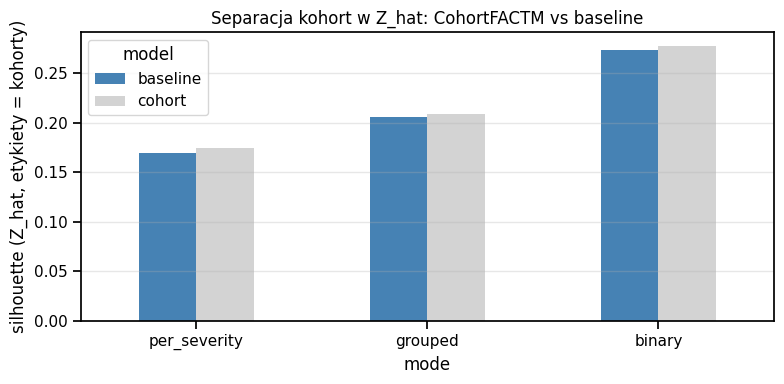

In [23]:
# 8b — wykres porównawczy silhouette (cohort vs baseline) per partycja
piv = df_sep.pivot(index='mode', columns='model', values='silhouette').loc[
    ['per_severity', 'grouped', 'binary']]
ax = piv.plot.bar(figsize=(8, 4), color=['steelblue', 'lightgray'], rot=0)
ax.set_ylabel('silhouette (Z_hat, etykiety = kohorty)')
ax.set_title('Separacja kohort w Z_hat: CohortFACTM vs baseline')
ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

Klastrowanie na poziomie kohort (D_fit, per_severity):
       method  k  silhouette
agglomerative  2       0.708
       kmeans  2       0.708
     spectral  2       0.708
agglomerative  3       0.609
       kmeans  3       0.609
     spectral  3       0.463
agglomerative  4       0.572
       kmeans  4       0.572
     spectral  4       0.572


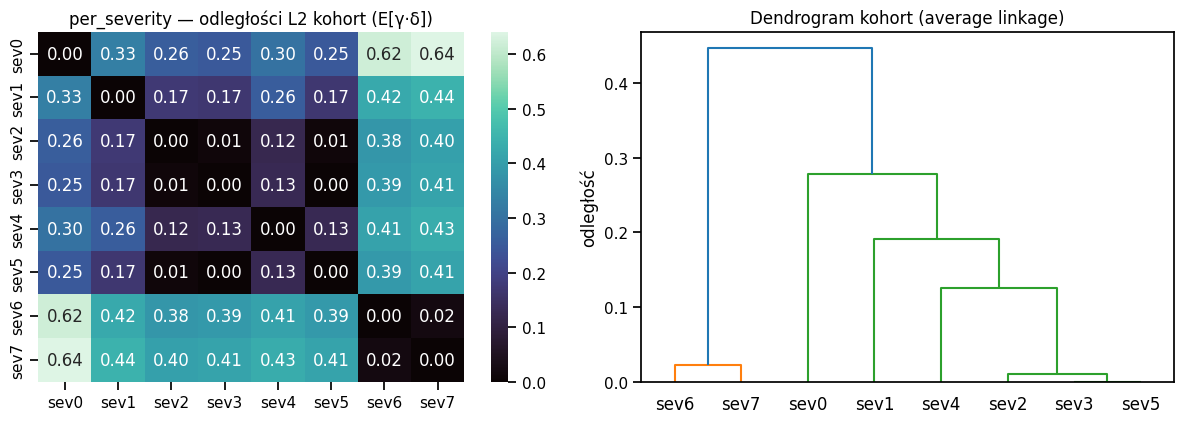

In [24]:
# 8c — klastrowanie na poziomie kohort (per_severity): macierz odległości E[γ·δ]
mode = 'per_severity'
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
d = get_data(mode)
out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
names = out['cohorts']
M_fit = out['E_gamma'] * out['E_delta']
D_fit = cohort_dist(M_fit)

df_cc, labels_cc = cluster_cohorts(D_fit, k_range=(2, 3, 4))
print('Klastrowanie na poziomie kohort (D_fit, per_severity):')
print(df_cc.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.heatmap(D_fit, annot=True, fmt='.2f', cmap='mako',
            xticklabels=names, yticklabels=names, ax=axes[0])
axes[0].set_title('per_severity — odległości L2 kohort (E[γ·δ])')
Zlink = linkage(squareform(D_fit, checks=False), method='average')
dendrogram(Zlink, labels=list(names), ax=axes[1],
           color_threshold=0.7 * Zlink[:, 2].max())
axes[1].set_title('Dendrogram kohort (average linkage)'); axes[1].set_ylabel('odległość')
plt.tight_layout(); plt.show()

Porownanie per partycja (k-means k = liczba kohort):
        mode    model  k        ELBO    R2  silhouette   ARI   NMI   AMI  V_measure   FMI
per_severity   cohort  8 -676521.530 0.392       0.174 0.553 0.502 0.484      0.502 0.647
per_severity baseline  8 -678491.713 0.392       0.169 0.554 0.504 0.485      0.504 0.647
     grouped   cohort  3 -676305.228 0.392       0.209 0.554 0.460 0.456      0.460 0.772
     grouped baseline  3 -678491.713 0.392       0.206 0.557 0.461 0.458      0.461 0.774
      binary   cohort  2 -676293.764 0.392       0.277 0.003 0.007 0.002      0.007 0.722
      binary baseline  2 -678491.713 0.392       0.273 0.611 0.491 0.490      0.491 0.816

Różnica cohort - baseline (dodatnia = cohort lepszy):
        mode    ΔELBO  ΔR2  Δsilhouette   ΔARI   ΔNMI   ΔAMI  ΔV_measure   ΔFMI
per_severity 1970.183 -0.0        0.004 -0.001 -0.001 -0.001      -0.001 -0.001
     grouped 2186.485 -0.0        0.003 -0.003 -0.002 -0.002      -0.002 -0.002
      binary 2197.949 

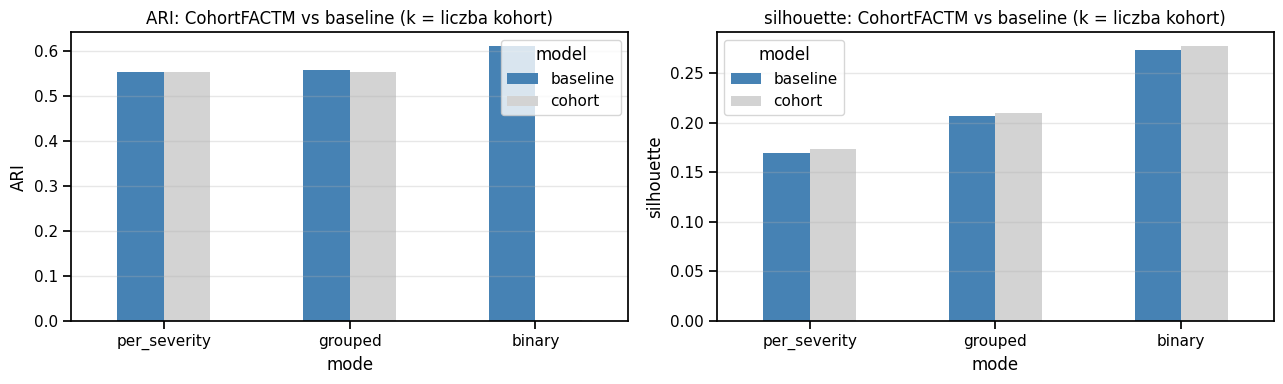

In [25]:
# 8d — Pełne porównanie baseline vs cohort + odzysk kohort.
# Klastrujemy Z_hat BEZ etykiet metodą k-means z **k = liczba kohort** i zestawiamy odzysk
# (ARI/NMI/AMI/V/FMI) z metrykami dopasowania (ELBO, R²) oraz separacji (silhouette
# prawdziwych kohort). Jedna tabela = pełne porównanie obu modeli na każdej partycji.
rows = []
for mode in ['per_severity', 'grouped', 'binary']:
    d = get_data(mode)
    views = d.views
    _, codes = np.unique(d.cohorts, return_inverse=True)
    C = len(np.unique(codes))                       # k-means: k = liczba kohort
    for kind in ['cohort', 'baseline']:
        m = get_fit(mode, kind, K=HEADLINE_K)
        Z = m.get_latent_factors()
        lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
        h, comp, v = homogeneity_completeness_v_measure(codes, lab)
        rows.append({'mode': mode, 'model': kind, 'k': C,
                     'ELBO': float(m.elbo_sequence[-1]),
                     'R2': mean_r2(m, views),
                     'silhouette': float(silhouette_score(Z, codes)),
                     'ARI': adjusted_rand_score(codes, lab),
                     'NMI': normalized_mutual_info_score(codes, lab),
                     'AMI': adjusted_mutual_info_score(codes, lab),
                     'V_measure': v,
                     'FMI': fowlkes_mallows_score(codes, lab)})
df_rec = pd.DataFrame(rows)
print('Porownanie per partycja (k-means k = liczba kohort):')
print(df_rec.round(3).to_string(index=False))

# Różnica cohort - baseline dla każdej metryki (dla wszystkich tu: wyżej = lepiej)
metr = ['ELBO', 'R2', 'silhouette', 'ARI', 'NMI', 'AMI', 'V_measure', 'FMI']
gap = []
for mode in ['per_severity', 'grouped', 'binary']:
    sub = df_rec[df_rec['mode'] == mode].set_index('model')
    gap.append({'mode': mode,
                **{f'Δ{x}': round(float(sub.loc['cohort', x] - sub.loc['baseline', x]), 3)
                   for x in metr}})
df_gap = pd.DataFrame(gap)
print('\nRóżnica cohort - baseline (dodatnia = cohort lepszy):')
print(df_gap.to_string(index=False))

# Wykres: ARI i silhouette obok siebie, cohort vs baseline, per partycja
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ['ARI', 'silhouette']):
    piv = df_rec.pivot(index='mode', columns='model', values=metric).loc[
        ['per_severity', 'grouped', 'binary']]
    piv.plot.bar(ax=ax, color=['steelblue', 'lightgray'], rot=0)
    ax.set_ylabel(metric); ax.set_title(f'{metric}: CohortFACTM vs baseline (k = liczba kohort)')
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

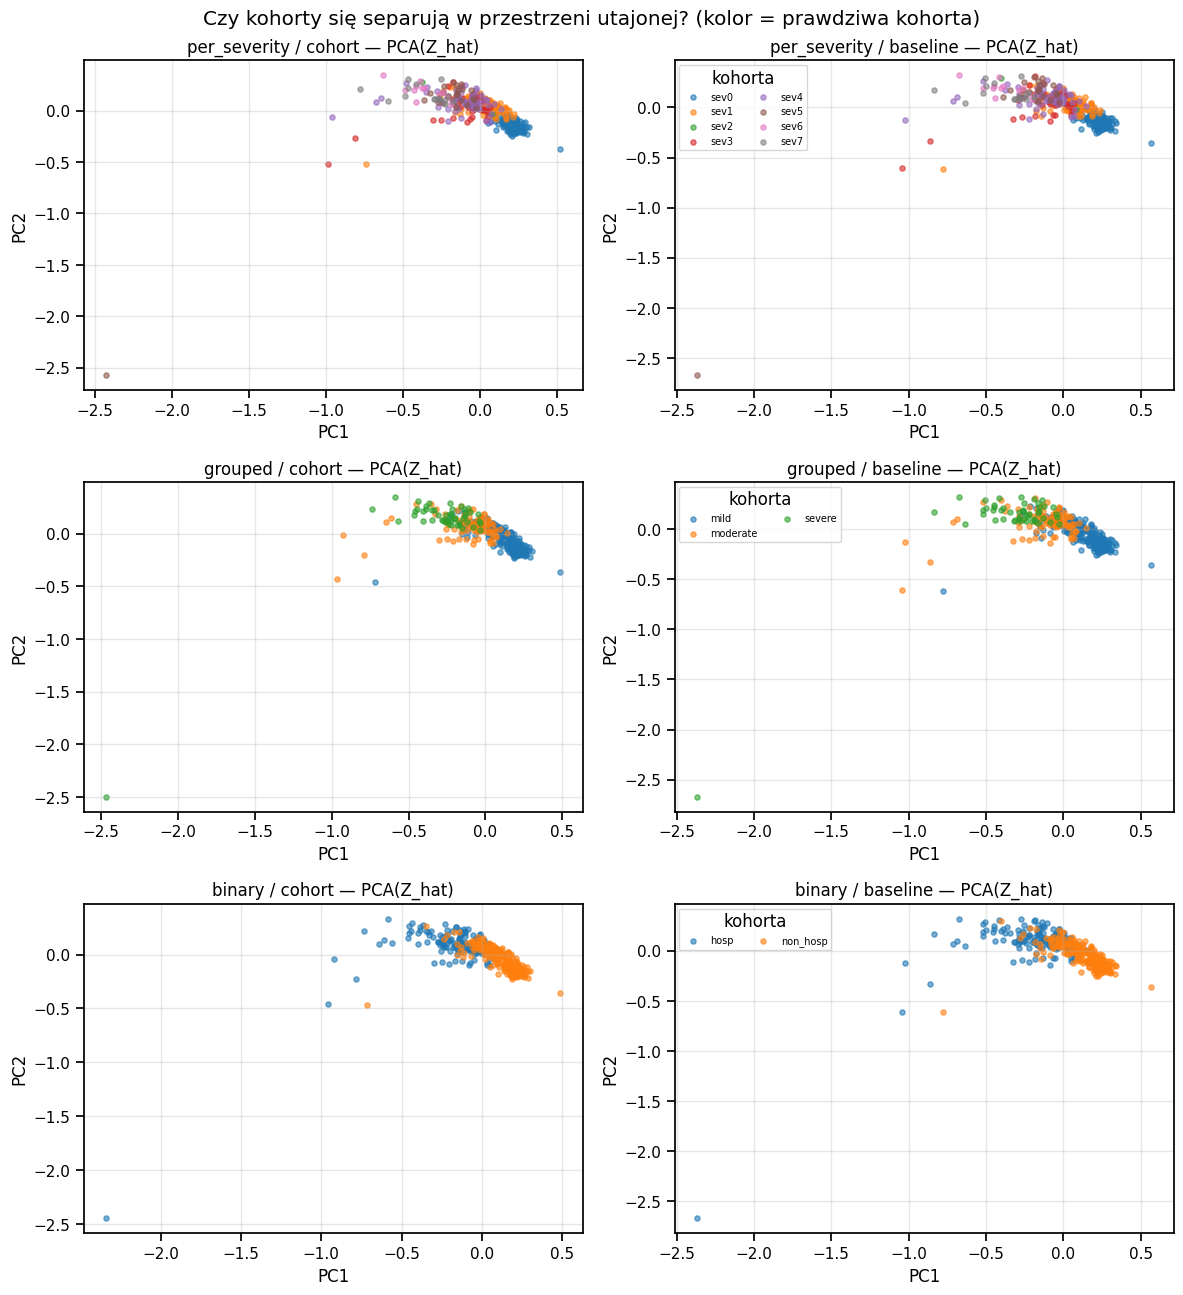

In [8]:
# 8e — wizualny dowód: czy kohorty tworzą skupiska w Z_hat? PCA cohort vs baseline (3 partycje)
modes = ['per_severity', 'grouped', 'binary']
fig, axes = plt.subplots(len(modes), 2, figsize=(12, 4.4 * len(modes)))
for r, mode in enumerate(modes):
    d = get_data(mode)
    names, codes = np.unique(d.cohorts, return_inverse=True)
    for cax, kind in zip(axes[r], ['cohort', 'baseline']):
        Z = get_fit(mode, kind, K=HEADLINE_K).get_latent_factors()
        P = PCA(n_components=2).fit_transform(Z)
        for i, name in enumerate(names):
            msk = codes == i
            cax.scatter(P[msk, 0], P[msk, 1], s=14, alpha=0.6, label=name)
        cax.set_title(f'{mode} / {kind} — PCA(Z_hat)')
        cax.set_xlabel('PC1'); cax.set_ylabel('PC2'); cax.grid(alpha=0.3)
    axes[r, 1].legend(fontsize=7, ncol=2, title='kohorta')
plt.suptitle('Czy kohorty się separują w przestrzeni utajonej? (kolor = prawdziwa kohorta)')
plt.tight_layout(); plt.show()

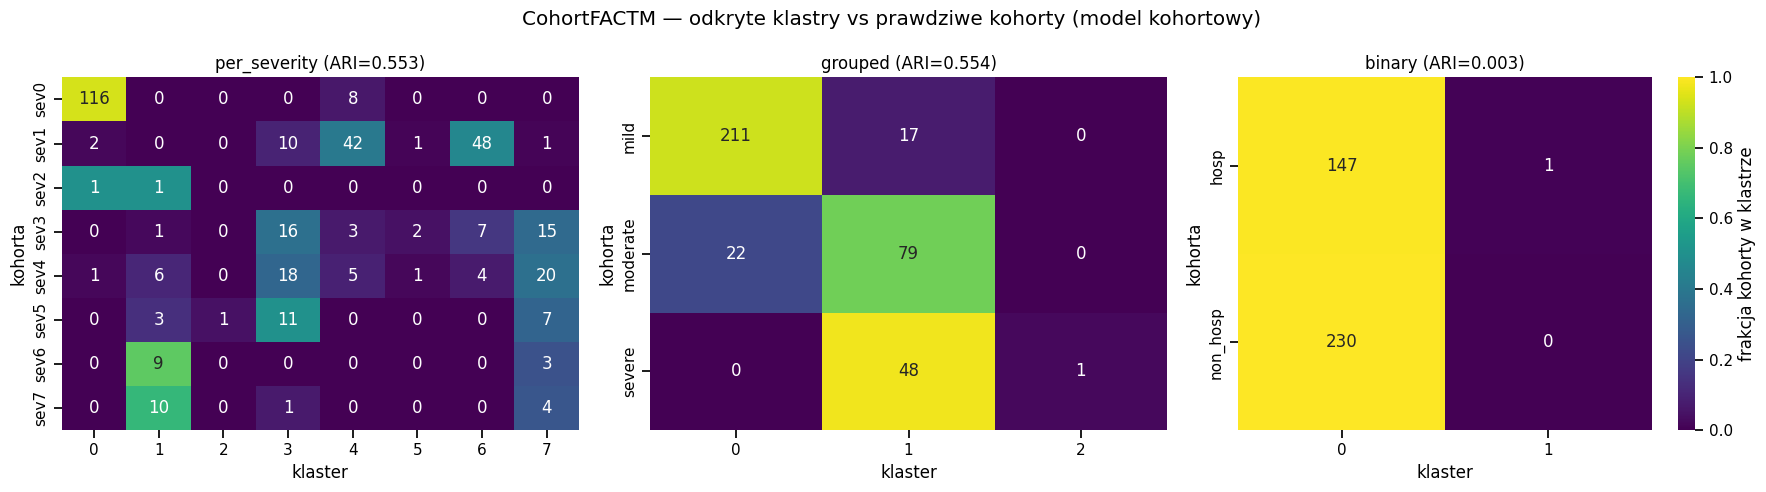

In [9]:
# 8f — macierz zgodności: odkryte klastry (k-means, k = liczba kohort) vs prawdziwe kohorty (3 partycje)
modes = ['per_severity', 'grouped', 'binary']
fig, axes = plt.subplots(1, len(modes), figsize=(6 * len(modes), 5))
for ax, mode in zip(axes, modes):
    d = get_data(mode)
    names, codes = np.unique(d.cohorts, return_inverse=True)
    C = len(names)
    Z = get_fit(mode, 'cohort', K=HEADLINE_K).get_latent_factors()
    lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
    ct = pd.crosstab(pd.Series(d.cohorts, name='kohorta'), pd.Series(lab, name='klaster'))
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct_norm, annot=ct.values, fmt='d', cmap='viridis', vmin=0, vmax=1,
                cbar=(ax is axes[-1]),
                cbar_kws={'label': 'frakcja kohorty w klastrze'}, ax=ax)
    ax.set_title(f'{mode} (ARI={adjusted_rand_score(codes, lab):.3f})')
plt.suptitle('CohortFACTM — odkryte klastry vs prawdziwe kohorty (model kohortowy)')
plt.tight_layout(); plt.show()

 pi  silhouette  davies_bouldin  calinski_harabasz  within/between
0.1       0.171           4.461             27.776           0.792
0.3       0.174           4.460             28.644           0.788
0.5       0.174           4.457             28.830           0.786
0.7       0.174           4.455             28.843           0.786
0.9       0.174           4.455             28.855           0.786


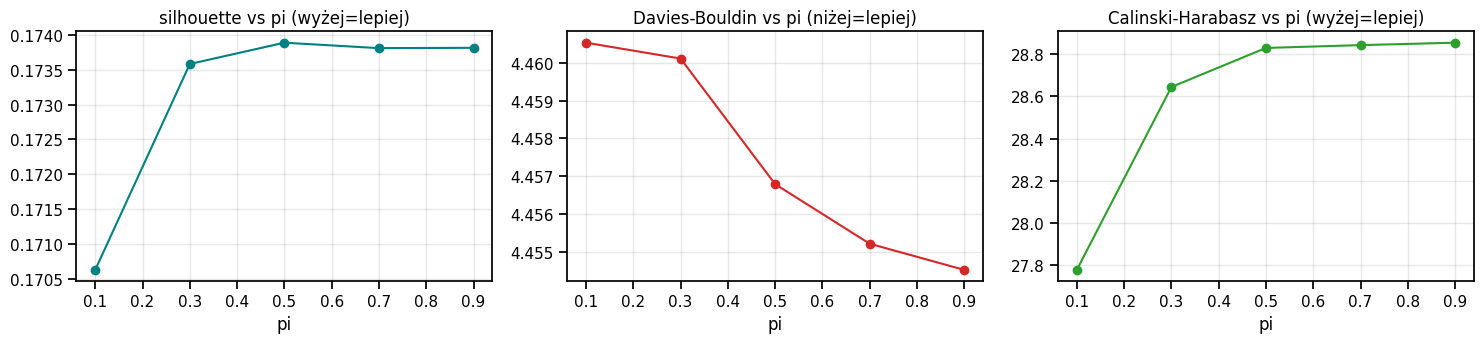

In [28]:
# 8g — jak separacja kohort zależy od pi (per_severity, K=5) — reużywa fitów z sekcji 6
mode = 'per_severity'
codes = np.unique(get_data(mode).cohorts, return_inverse=True)[1]
rows = []
for pi in PI_GRID:
    mp = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
    rows.append({'pi': pi, **clustering_metrics(mp.get_latent_factors(), codes)})
df_sil = pd.DataFrame(rows)
print(df_sil.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(df_sil['pi'], df_sil['silhouette'], 'o-', color='teal')
axes[0].set_title('silhouette vs pi (wyżej=lepiej)')
axes[1].plot(df_sil['pi'], df_sil['davies_bouldin'], 'o-', color='C3')
axes[1].set_title('Davies-Bouldin vs pi (niżej=lepiej)')
axes[2].plot(df_sil['pi'], df_sil['calinski_harabasz'], 'o-', color='C2')
axes[2].set_title('Calinski-Harabasz vs pi (wyżej=lepiej)')
for ax in axes:
    ax.set_xlabel('pi'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Jak czytać.** Klastrujemy `Z_hat` **bez etykiet** (k-means, `k = liczba kohort`) i
porównujemy odzysk z prawdziwymi kohortami. Wynik na danych COVID:

* `per_severity` i `grouped`: cohort ≈ baseline (ARI ~0.55) — kohorty są częściowo
  odzyskiwalne z `Z_hat`, a prior ich nie pogarsza.
* `binary`: cohort wypada **gorzej** (ARI ~0.00 vs baseline ~0.61). To **nie błąd**: przy 2
  kohortach prior wchłania różnicę `hosp/non_hosp` do przesunięcia `γ·δ` (patrz sekcje 2 i
  5), więc w samym `Z_hat` dominuje inna oś (np. gradient nasilenia), wzdłuż której k-means
  dzieli próbki — zamiast podziału hosp/non_hosp.

**Wniosek metodologiczny:** dla modelu kohortowego właściwym miejscem „wykrycia" kohort jest
`γ·δ` (sekcje 2, 5 oraz klastrowanie kohort w 8c), a **nie** spread `Z_hat`. Klastrowanie
`Z_hat` (8d–8f) to test komplementarny — mówi, ile sygnału kohortowego zostaje w przestrzeni
próbek po odjęciu przesunięć kohortowych. PCA (8e) i macierz zgodności (8f) pokazują to wprost.


## 9 — Wagi `W` i istotność faktorów (z `02_w_loadings`)

Co konkretnie model wyciągnął z cech? Patrzymy na nauczone ładunki `E[W]` (które cechy
budują dany faktor) oraz na istotność faktorów wg ARD — które faktory są „żywe", a które
wygaszone.

> Uwaga o rzadkości: spike-and-slab `E[S]` w tym modelu zostaje ≈ 1, więc istotność
> oceniamy energią `‖W[:,k]‖` i precyzją ARD `E[α]` (małe α = faktor istotny), nie `E[S]`.


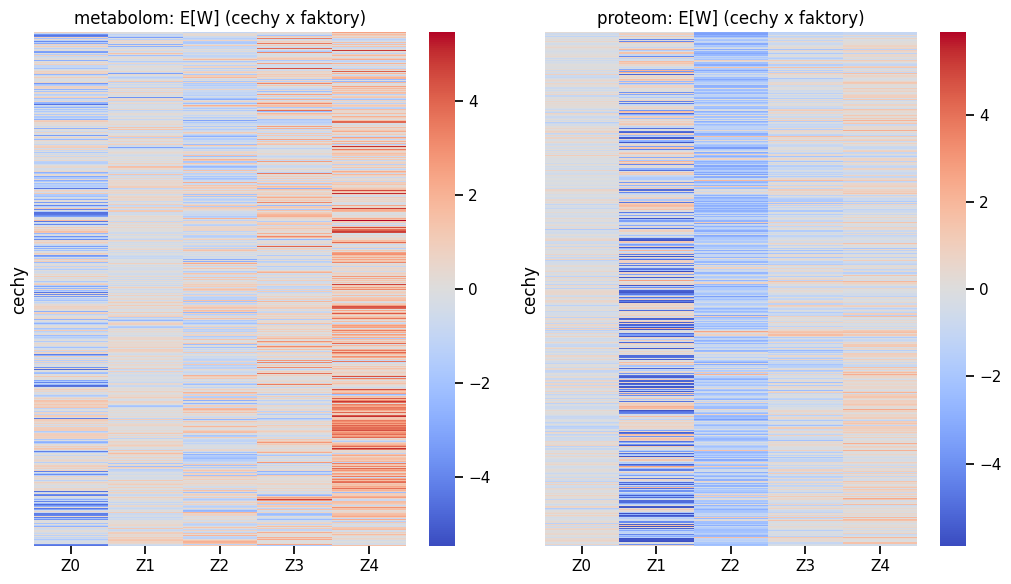

In [29]:
# 9a — nauczone ładunki E[W] per widok (per_severity, K=5)
mode = 'per_severity'
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
views = get_data(mode).views
factors = [f'Z{k}' for k in range(HEADLINE_K)]
view_names = ['metabolom', 'proteom']

fig, axes = plt.subplots(1, views.num_simple, figsize=(5.2 * views.num_simple, 6))
for v in range(views.num_simple):
    E_w = get_W(mc, v)
    vmax = np.abs(E_w).max()
    sns.heatmap(E_w, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
                xticklabels=factors, yticklabels=False, ax=axes[v])
    axes[v].set_title(f'{view_names[v]}: E[W] (cechy x faktory)')
    axes[v].set_ylabel('cechy')
plt.tight_layout(); plt.show()

    ‖W[:,k]‖ (energia)  1/E[alpha] (ARD)  var(Z[:,k])
Z0              53.458             2.763        0.043
Z1              22.534             0.549        0.024
Z2              35.475             1.234        0.050
Z3              38.579             1.494        0.022
Z4              59.871             3.491        0.023


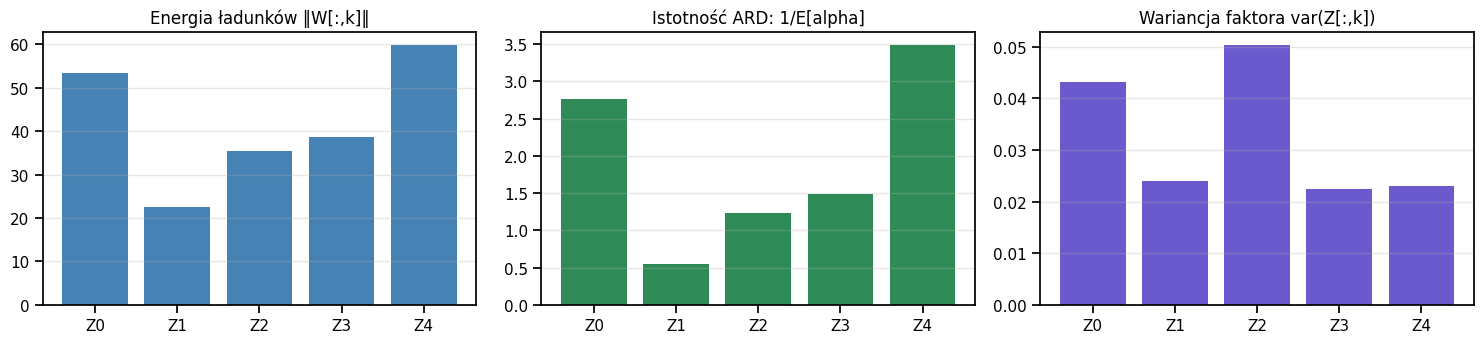

In [30]:
# 9b — istotność faktorów: energia ‖W‖, ARD 1/E[alpha], var(Z)
W0 = get_W(mc, 0)
energy = np.linalg.norm(W0, axis=0)
relevance = 1.0 / factor_alpha(mc, 0)
zvar = mc.get_latent_factors().var(0)
tab = pd.DataFrame({'‖W[:,k]‖ (energia)': energy.round(3),
                    '1/E[alpha] (ARD)':   relevance.round(3),
                    'var(Z[:,k])':        zvar.round(3)}, index=factors)
print(tab.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].bar(factors, energy, color='steelblue');  axes[0].set_title('Energia ładunków ‖W[:,k]‖')
axes[1].bar(factors, relevance, color='seagreen'); axes[1].set_title('Istotność ARD: 1/E[alpha]')
axes[2].bar(factors, zvar, color='slateblue');     axes[2].set_title('Wariancja faktora var(Z[:,k])')
for ax in axes:
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

**Jak czytać.** Heatmapy `E[W]` pokazują blokową strukturę cech → faktory. Faktory o
niskiej energii i wysokim `α` zostały wygaszone przez ARD (potwierdza efektywną liczbę
faktorów z sekcji 2); faktory o wysokiej energii i wariancji niosą realny sygnał.


## 10 — Podsumowanie

Notebook odtworzył na danych COVID-19 pełen zestaw testów kohortowych:

1. **Profile `E[γ]` / `E[γ·δ]`** dla trzech partycji (`per_severity`, `grouped`, `binary`)
   — które czynniki różnią kohorty i jak silnie.
2. **Sweep `K = 3…10, 15, 20`** — ile czynników kohortowych model aktywuje, R² rekonstrukcji
   i liczba istotnych faktorów (ARD) vs `K`, ELBO cohort vs baseline.
3. **Struktura odległości + korelacja z nasileniem WHO** — czy gradient ciężkości jest
   zachowany w przestrzeni utajonej (cohort vs baseline).
4. **Sweep `pi` dla `K ∈ {3,5,10}`** — wrażliwość aktywacji kohortowej na prior
   spike-and-slab.
5. **Struktura faktorów `Z`** — korelacje faktorów, powiązanie z nasileniem WHO, centroidy
   kohort.
6. **Wykrywanie klastrów** — odzysk kohort z `Z_hat` bez etykiet (k-means), komplet metryk
   (ARI, NMI, AMI, V-measure, FMI) cohort vs baseline, PCA i macierz zgodności.
7. **Wagi `W` i istotność faktorów** — nauczone ładunki `E[W]` i istotność ARD per faktor.

Werdykt formułujemy z tabel powyżej: CohortFACTM jest uzasadniony, gdy (a) ELBO ≥ baseline,
(b) odległości kohort korelują z nasileniem WHO lepiej lub na równi z baseline, (c) kohorty
są lepiej odzyskiwalne z `Z_hat` (ARI/NMI ≥ baseline) i widoczne jako skupiska na PCA.
